In [ ]:
!pip -q install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip -q install trl datasets accelerate peft bitsandbytes transformers sentencepiece evaluate matplotlib pandas
!pip -q install lm-eval

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 116.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.2/421.2 kB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 96.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 120.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 24.2 MB/s eta 0:00:00


# HW 5

In [63]:
import os, gc, math, time, json, random
import unsloth
import numpy as np
import pandas as pd
import torch
import getpass
import matplotlib.pyplot as plt
import lm_eval
import glob

from datasets import load_dataset, DatasetDict
from transformers import TrainingArguments, EarlyStoppingCallback
from transformers import DataCollatorForLanguageModeling
from torch.utils.data import DataLoader
from torch.profiler import profile, ProfilerActivity
from peft import PeftModel


from unsloth.chat_templates import get_chat_template
from unsloth import FastLanguageModel
from trl import SFTTrainer, SFTConfig

In [ ]:
HF_TOKEN = getpass.getpass("HF_TOKEN: ")

HF_TOKEN: ··········


In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [ ]:
DATASET_NAME = "d0rj/alpaca-cleaned-ru"
MODEL_NAME = "unsloth/Qwen3-0.6B"
MAX_SEQ_LENGTH = 1024
TRAIN_ROWS = 6000
PACKING = True

In [ ]:
def cuda_mem(label=""):
    if not torch.cuda.is_available():
        print("CUDA not available")
        return
    torch.cuda.synchronize()
    allocated = torch.cuda.memory_allocated() / 1024**2
    reserved = torch.cuda.memory_reserved() / 1024**2
    max_alloc = torch.cuda.max_memory_allocated() / 1024**2
    print(f"[VRAM] {label} allocated={allocated:.0f} MB | reserved={reserved:.0f} MB | max_alloc={max_alloc:.0f} MB")

In [ ]:
def reset_cuda_peak():
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

In [ ]:
cuda_mem("start")

[VRAM] start allocated=8 MB | reserved=22 MB | max_alloc=8 MB


## Загрузка датасета

In [ ]:
raw_datasets = load_dataset(DATASET_NAME)

README.md:   0%|          | 0.00/760 [00:00<?, ?B/s]

data/train-00000-of-00001-c503683bee003a(…):   0%|          | 0.00/36.6M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/51760 [00:00<?, ? examples/s]

In [ ]:
raw = raw_datasets["train"].shuffle(seed=SEED).select(
    range(min(TRAIN_ROWS, len(raw_datasets["train"])))
)

dataset = raw.train_test_split(test_size=0.02, seed=SEED)
train_dataset = dataset["train"]
eval_dataset = dataset["test"]

In [ ]:
(
    f"Train: {len(train_dataset):,} | "
    f"Eval: {len(eval_dataset):,}"
)

'Train: 5,880 | Eval: 120'

In [ ]:
train_dataset.column_names

['input', 'instruction', 'output']

In [ ]:
row = {
    "input": train_dataset[0]["input"],
    "instruction": train_dataset[0]["instruction"],
    "output": train_dataset[0]["output"],
}
print(json.dumps(row, ensure_ascii=False, indent=2))

{
  "input": "Собака громко залаяла.",
  "instruction": "Переведите следующий текст от первого лица.",
  "output": "Я громко залаял."
}


## Загрузка модели (4-bit) + включение chat template

In [ ]:
reset_cuda_peak()

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=None,
    load_in_4bit=True,
)

cuda_mem("after model load (4bit)")

==((====))==  Unsloth 2026.4.6: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/576M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/237 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

unsloth/qwen3-0.6b-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
[VRAM] after model load (4bit) allocated=592 MB | reserved=626 MB | max_alloc=608 MB


In [ ]:
tokenizer.chat_template

'{%- if tools %}\n    {{- \'<|im_start|>system\\n\' }}\n    {%- if messages[0].role == \'system\' %}\n        {{- messages[0].content + \'\\n\\n\' }}\n    {%- endif %}\n    {{- "# Tools\\n\\nYou may call one or more functions to assist with the user query.\\n\\nYou are provided with function signatures within <tools></tools> XML tags:\\n<tools>" }}\n    {%- for tool in tools %}\n        {{- "\\n" }}\n        {{- tool | tojson }}\n    {%- endfor %}\n    {{- "\\n</tools>\\n\\nFor each function call, return a json object with function name and arguments within <tool_call></tool_call> XML tags:\\n<tool_call>\\n{\\"name\\": <function-name>, \\"arguments\\": <args-json-object>}\\n</tool_call><|im_end|>\\n" }}\n{%- else %}\n    {%- if messages[0].role == \'system\' %}\n        {{- \'<|im_start|>system\\n\' + messages[0].content + \'<|im_end|>\\n\' }}\n    {%- endif %}\n{%- endif %}\n{%- set ns = namespace(multi_step_tool=true, last_query_index=messages|length - 1) %}\n{%- for forward_message 

In [ ]:
def alpaca_row_to_user_text(example: dict) -> str:
    instr = (example.get("instruction") or "").strip()
    inp = (example.get("input") or "").strip()
    if inp:
        return f"{instr}\n\n{inp}"
    return instr


def to_messages(example: dict) -> list[dict]:
    user = alpaca_row_to_user_text(example)
    assistant = (example.get("output") or "").strip()
    return [
        {"role": "system", "content": "Ты — полезный русскоязычный ассистент."},
        {"role": "user", "content": user},
        {"role": "assistant", "content": assistant},
    ]


def format_text(example: dict) -> dict:
    messages = to_messages(example)
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False,
    )
    return {"text": text, "messages_norm": messages}

In [ ]:
train_dataset = train_dataset.map(format_text, remove_columns=train_dataset.column_names)
eval_dataset = eval_dataset.map(format_text, remove_columns=eval_dataset.column_names)


Map:   0%|          | 0/5880 [00:00<?, ? examples/s]

Map:   0%|          | 0/120 [00:00<?, ? examples/s]

In [ ]:
row = {
    "text": train_dataset[1]["text"],
    "messages_norm": train_dataset[1]["messages_norm"],
}
print(json.dumps(row, ensure_ascii=False, indent=2))

{
  "text": "<|im_start|>system\nТы — полезный русскоязычный ассистент.<|im_end|>\n<|im_start|>user\nСравните производительность модели линейной регрессии с моделью нейронной сети.<|im_end|>\n<|im_start|>assistant\n<think>\n\n</think>\n\nЛинейная регрессия и нейронные сети используются для прогнозного моделирования, но они различаются по своей структуре и подходу к решению проблем.\n\nМодель линейной регрессии — это простой алгоритм, который подгоняет линию к набору точек данных таким образом, чтобы минимизировать сумму квадратов невязок. Эта модель лучше всего подходит для задач, где связь между входными и выходными переменными является линейной.\n\nС другой стороны, нейронная сеть представляет собой многослойную структуру, состоящую из взаимосвязанных нейронов, где отношения между нейронами каждого слоя моделируются взвешенными связями, которые обучаются с помощью данных. В отличие от линейной регрессии нейронные сети могут моделировать сложные нелинейные отношения между входными и в

## Аудит данных

In [ ]:
def conversation_token_count(messages) -> int:
    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=False
    )
    return len(tokenizer(text, add_special_tokens=False).input_ids)

In [ ]:
SAMPLE_CAP = 3000
subset = train_dataset.shuffle(seed=SEED).select(
    range(min(SAMPLE_CAP, len(train_dataset)))
)
lens = [conversation_token_count(row["messages_norm"]) for row in subset]

stats = pd.Series(lens).describe(percentiles=[0.5, 0.9, 0.95, 0.99])
print("Token length statistics:")
print(stats.to_string())


Token length statistics:
count    3000.000000
mean      294.801667
std       210.054917
min        55.000000
50%       236.000000
90%       610.100000
95%       693.000000
99%       862.010000
max      1033.000000


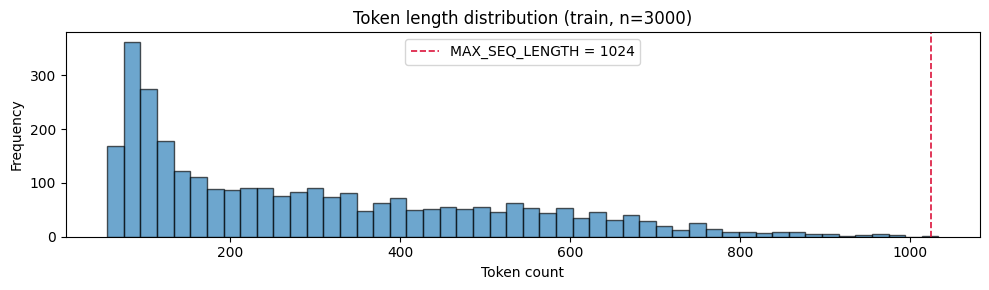

In [ ]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(lens, bins=50, edgecolor="black", alpha=0.65)
ax.axvline(
    MAX_SEQ_LENGTH,
    color="crimson",
    linestyle="--",
    linewidth=1.2,
    label=f"MAX_SEQ_LENGTH = {MAX_SEQ_LENGTH}",
)
ax.set_xlabel("Token count")
ax.set_ylabel("Frequency")
ax.set_title(f"Token length distribution (train, n={len(lens)})")
ax.legend()
plt.tight_layout()
plt.show()

within = sum(l <= MAX_SEQ_LENGTH for l in lens)

In [ ]:
print(
    f"\n{100 * within / len(lens):.1f}% of samples are within MAX_SEQ_LENGTH={MAX_SEQ_LENGTH}"
)


100.0% of samples are within MAX_SEQ_LENGTH=1024


Гистограмма и процентили выше показывают, что подавляющее большинство диалогов укладывается в `MAX_SEQ_LENGTH=1024` токенов. Усечений почти нет, выбранная длина контекста адекватна распределению.

## Предварительная оценка качества

In [ ]:
prompts_for_test = [
    'Как улучшить качество сна без лекарств?',
    'Каковы основные причины изменения климата?',
    'Какие признаки указывают на обезвоживание организма?',
    'Объясни, что такое квантовая запутанность простыми словами',
    'Какие документы нужны для оформления наследства?',
    'Расскажи про жизнь и открытия Менделеева'
]

In [ ]:
FastLanguageModel.for_inference(model)

Qwen3ForCausalLM(
  (model): Qwen3Model(
    (embed_tokens): Embedding(151936, 1024, padding_idx=151669)
    (layers): ModuleList(
      (0): Qwen3DecoderLayer(
        (self_attn): Qwen3Attention(
          (q_proj): Linear(in_features=1024, out_features=2048, bias=False)
          (k_proj): Linear(in_features=1024, out_features=1024, bias=False)
          (v_proj): Linear(in_features=1024, out_features=1024, bias=False)
          (o_proj): Linear(in_features=2048, out_features=1024, bias=False)
          (q_norm): Qwen3RMSNorm((128,), eps=1e-06)
          (k_norm): Qwen3RMSNorm((128,), eps=1e-06)
          (rotary_emb): LlamaRotaryEmbedding()
        )
        (mlp): Qwen3MLP(
          (gate_proj): Linear4bit(in_features=1024, out_features=3072, bias=False)
          (up_proj): Linear4bit(in_features=1024, out_features=3072, bias=False)
          (down_proj): Linear4bit(in_features=3072, out_features=1024, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_lay

In [ ]:
def generate_chat(
    model,
    tokenizer,
    user_text,
    system_text="Ты — полезный русскоязычный ассистент.",
    max_new_tokens=256,
):
    messages = [
        {"role": "system", "content": system_text},
        {"role": "user", "content": user_text},
    ]
    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False,
    )
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            max_length=None,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            repetition_penalty=1.05,
            pad_token_id=tokenizer.eos_token_id,
        )
    return tokenizer.decode(out[0], skip_special_tokens=True)

In [ ]:
model.device

device(type='cuda', index=0)

In [120]:
reset_cuda_peak()
cuda_mem("pre-train eval start")

for p in prompts_for_test:
    print(f"PROMPT: {p}")
    print(generate_chat(model, tokenizer, p)[:2000])
    print("=" * 120)

cuda_mem("pre-train eval end")

[VRAM] pre-train eval start allocated=2053 MB | reserved=2098 MB | max_alloc=2053 MB
PROMPT: Как улучшить качество сна без лекарств?


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


system
Ты — полезный русскоязычный ассистент.
user
Как улучшить качество сна без лекарств?
assistant
<think>

</think>

Существует множество способов улучшить качество сна, которые вы можете использовать для улучшения вашей физической и мозговой функции. Вот несколько рекомендаций:

1. Начните с того, чтобы настроиться на дыхательную технику: поддерживайте дыхательную технику, используя ритмичные глубокие дыхания. Это помогает вам снизить чувство тревоги и расслабиться.

2. Уберите из вашей повседневной жизни некоторые стрессовые факторы. Избегайте избыточных негативных мыслей и переживаниях, таких как тревога или стресс. Принимайте больше отдыха и отдыха, чтобы снять напряжение и восстановить ваше здоровье.

3. Заняться спорт или тренировкой: спорт и тренировка могут помочь вам снизить уровень стресса и улучшить вашу физическую активность. Вы можете пройти 30-минутный трек или пройти физическую
PROMPT: Каковы основные причины изменения климата?
system
Ты — полезный русскоязычный ассис

### Наблюдения по baseline

Базовая модель до дообучения:
- формально отвечает по-русски, но язык часто “ломаный”: встречаются несуществующие слова и странные формулировки;
- теряет логическую связность: в ответах появляются абсурдные или противоречивые утверждения (например, некорректные советы или псевдонаучные причины);
- допускает ошибки в фактах
- иногда “разваливается” по ходу генерации: ответы обрываются, появляется мусорный или бессвязный текст.

Задача SFT: улучшить качество языка, восстановить логическую связность и сделать ответы содержательными и структурированными.

## Бенчмарк до обучения (LM Evaluation Harness)

In [ ]:
BASE_BENCH_DIR = "/content/bench_base"
os.makedirs(BASE_BENCH_DIR, exist_ok=True)

In [40]:
!lm_eval \
  --model hf \
  --model_args pretrained={MODEL_NAME},trust_remote_code=True \
  --tasks truthfulqa_mc2 \
  --device cuda:0 \
  --batch_size 8 \
  --limit 50 \
  --output_path {BASE_BENCH_DIR}/truthfulqa_base.json

2026-04-22:12:30:50 WARNING  [config.evaluate_config:281] --limit SHOULD ONLY BE USED FOR TESTING. REAL METRICS SHOULD NOT BE COMPUTED USING LIMIT.
2026-04-22:12:30:59 INFO     [_cli.run:376] Selected Tasks: ['truthfulqa_mc2']
2026-04-22:12:30:59 INFO     [evaluator:211] Setting random seed to 0 | Setting numpy seed to 1234 | Setting torch manual seed to 1234 | Setting fewshot manual seed to 1234
2026-04-22:12:30:59 INFO     [evaluator:236] Initializing hf model, with arguments: {'pretrained': 'unsloth/Qwen3-0.6B', 'trust_remote_code': True}
2026-04-22:12:31:04 INFO     [models.huggingface:161] Using device 'cuda:0'
2026-04-22:12:31:05 INFO     [models.huggingface:423] Model parallel was set to False, max memory was not set, and device map was set to {'': 'cuda:0'}
Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
Loading weights: 100% 310/310 [00:03<00:00, 81.80it/s]
2026-04-22:12:31:12 INFO     [tasks:700] Sel

## QLora-дообучение

Берём `r=16` — стандартный выбор для моделей ~1B, получаем примерно 1-2% обучаемых параметров. `target_modules` — не только attention, но и MLP: именно MLP отвечает за содержание ответа, а для instruction-датасета это важнее, чем дополнительно дообучать внимание. Gradient checkpointing, чтобы на T4 по памяти пролезть.

In [ ]:
def add_lora(model, r=16, lora_alpha=32, target="attn_mlp", dropout=0.05):
    if target == "attn":
        target_modules = ["q_proj", "k_proj", "v_proj", "o_proj"]
    else:
        target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                          "gate_proj", "up_proj", "down_proj"]

    model = FastLanguageModel.get_peft_model(
        model,
        r=r,
        lora_alpha=lora_alpha,
        lora_dropout=dropout,
        bias="none",
        target_modules=target_modules,
        use_gradient_checkpointing=True,
        random_state=SEED,
        use_rslora=False,
    )
    return model, target_modules

In [ ]:
def trainable_params_report(model):
    trainable = 0
    total = 0
    for p in model.parameters():
        n = p.numel()
        total += n
        if p.requires_grad:
            trainable += n
    return {
        "trainable": trainable,
        "total": total,
        "trainable_pct": 100 * trainable / total,
    }

In [ ]:
del model
gc.collect()
torch.cuda.empty_cache()
reset_cuda_peak()

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=None,
    load_in_4bit=True,
)

tokenizer.pad_token = tokenizer.eos_token
tokenizer.pad_token_id = tokenizer.eos_token_id
model.config.pad_token_id = tokenizer.pad_token_id
if getattr(model, "generation_config", None) is not None:
    model.generation_config.pad_token_id = tokenizer.pad_token_id

model, target_modules = add_lora(model, r=16, lora_alpha=32, target="attn_mlp")

rep = trainable_params_report(model)
print(f"Target modules : {target_modules}")
print(f"Trainable      : {rep['trainable']:,} / {rep['total']:,}  ({rep['trainable_pct']:.2f}%)")

cuda_mem("after lora init")

==((====))==  Unsloth 2026.4.6: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

unsloth/qwen3-0.6b-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.4.6 patched 28 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


Target modules : ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']
Trainable      : 10,092,544 / 398,524,416  (2.53%)
[VRAM] after lora init allocated=1260 MB | reserved=1290 MB | max_alloc=1261 MB


Обучаемых параметров получилось ~2,5% от общего числа. В этом суть **QLoRA**: замороженная 4-битная база (экономит VRAM на весах) + маленький fp16-адаптер (экономит на градиентах и состояниях оптимизатора).

## Обучение SFT (TRL)

In [ ]:
args = SFTConfig(
    output_dir="sft_runs/main",
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    weight_decay=0.01,
    max_steps=200,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=20,
    save_strategy="steps",
    save_steps=20,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    optim="paged_adamw_8bit",
    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),

    report_to="none",
    seed=SEED,
    dataset_text_field="text",
    max_length=MAX_SEQ_LENGTH,
    packing=PACKING,
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [ ]:
trainer = SFTTrainer(
    model=model,
    processing_class=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    args=args,
)

trainer.add_callback(EarlyStoppingCallback(early_stopping_patience=2))

Unsloth: Sample packing skipped (custom data collator detected).


In [ ]:
cuda_mem("before train")
t0 = time.time()
train_out = trainer.train()
t1 = time.time()
cuda_mem("after train")
print(f"Train time: {(t1 - t0) / 60:.1f} min")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


[VRAM] before train allocated=1260 MB | reserved=1290 MB | max_alloc=1261 MB


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 5,880 | Num Epochs = 1 | Total steps = 200
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 10,092,544 of 606,142,464 (1.67% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss,Validation Loss
20,1.721505,1.548949
40,1.525061,1.436739
60,1.432213,1.410377
80,1.360593,1.398915
100,1.422602,1.385934
120,1.413536,1.376517
140,1.407128,1.370234
160,1.431489,1.363935


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 

Step,Training Loss,Validation Loss
20,1.721505,1.548949
40,1.525061,1.436739
60,1.432213,1.410377
80,1.360593,1.398915
100,1.422602,1.385934
120,1.413536,1.376517
140,1.407128,1.370234
160,1.431489,1.363935
180,1.371007,1.362246
200,1.375425,1.361997


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 

[VRAM] after train allocated=1276 MB | reserved=1348 MB | max_alloc=2793 MB
Train time: 12.8 min


## Оценка качества обучения


### Корзинка промптов после обучения

In [41]:
FastLanguageModel.for_inference(trainer.model)

for p in prompts_for_test:
    print(f"PROMPT: {p}")
    print(generate_chat(trainer.model, tokenizer, p)[:2000])
    print("=" * 120)

PROMPT: Как улучшить качество сна без лекарств?


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


system
Ты — полезный русскоязычный ассистент.
user
Как улучшить качество сна без лекарств?
assistant
<think>

</think>

Вот несколько советов, которые помогут улучшить качество сна:

1. Студировать: Улучшите вашу физическую активность. Практикуйте легкое спортивное тренирование или занимайтесь упражнениями в форме, чтобы улучшить вашу физическую активность и укрепить вашу здоровье, что может помочь вам соннуть лучше.

2. Соблюдайте режим сна. Начните с того, чтобы придерживаться своих режимов сна, таких как 7-10 часов в сутки. Найдите время, когда вы хотите сходить в заслуживать, чтобы у вас были свободные моменты для отдыха и размышления, но также придерживаясь строгого режима сна, вы можете снизить риск развития сильной депрессии и сонливых состояний.

3. Установите привычки. Прежде чем попробовать изменить свое сонство, посмотрите на свои привычки и уберите из них. Например, убедитесь, что
PROMPT: Каковы основные причины изменения климата?
system
Ты — полезный русскоязычный ассистен

### Сравнение с baseline

Новая генерация:
- язык стал немного чище, но всё ещё заметно “ломаный”: ошибки реже, но странные слова и формулировки сохраняются;
- логика слегка улучшилась: ответы чаще держатся в рамках темы, но по-прежнему содержат абсурд и искажения;
- фактическая точность всё ещё низкая (например, полностью неверный ответ про Менделеева);
- структура стала чуть стабильнее: списки выглядят более оформленными, меньше явных обрывов;

**Итог:** есть небольшое улучшение по форме и стабильности, но по содержанию модель всё ещё слабая, ошибки, шум и недостоверность остаются доминирующими.

In [42]:
ADAPTER_DIR = "/content/artifacts/adapter_only"
os.makedirs(ADAPTER_DIR, exist_ok=True)

trainer.model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)

print("Adapter saved to:", ADAPTER_DIR)

Adapter saved to: /content/artifacts/adapter_only


## Бенчмарк после обучения (LM Evaluation Harness)

In [43]:
SFT_BENCH_DIR = "/content/bench_sft"
os.makedirs(SFT_BENCH_DIR, exist_ok=True)

!lm_eval \
  --model hf \
  --model_args pretrained={MODEL_NAME},peft={ADAPTER_DIR},trust_remote_code=True \
  --tasks truthfulqa_mc2 \
  --device cuda:0 \
  --batch_size 8 \
  --limit 50 \
  --output_path {SFT_BENCH_DIR}/truthfulqa_sft.json

2026-04-22:12:34:53 WARNING  [config.evaluate_config:281] --limit SHOULD ONLY BE USED FOR TESTING. REAL METRICS SHOULD NOT BE COMPUTED USING LIMIT.
2026-04-22:12:35:05 INFO     [_cli.run:376] Selected Tasks: ['truthfulqa_mc2']
2026-04-22:12:35:05 INFO     [evaluator:211] Setting random seed to 0 | Setting numpy seed to 1234 | Setting torch manual seed to 1234 | Setting fewshot manual seed to 1234
2026-04-22:12:35:05 INFO     [evaluator:236] Initializing hf model, with arguments: {'pretrained': 'unsloth/Qwen3-0.6B', 'peft': '/content/artifacts/adapter_only', 'trust_remote_code': True}
2026-04-22:12:35:10 INFO     [models.huggingface:161] Using device 'cuda:0'
2026-04-22:12:35:12 INFO     [models.huggingface:423] Model parallel was set to False, max memory was not set, and device map was set to {'': 'cuda:0'}
Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
Loading weights: 100% 310/310 [00:00<00:00, 685.93it/s]


In [45]:
def read_lm_eval(directory, pattern="*.json"):
    paths = glob.glob(os.path.join(directory, pattern))
    if not paths:
        raise FileNotFoundError(f"No results found in {directory}")
    with open(sorted(paths)[-1], "r", encoding="utf-8") as f:
        return json.load(f).get("results", {})

base_res = read_lm_eval(BASE_BENCH_DIR)
sft_res  = read_lm_eval(SFT_BENCH_DIR)

task = "truthfulqa_mc2"
print(f"{'Metric':<20} {'Base':>10} {'SFT':>10} {'Delta':>10}")
print("-" * 52)
for k, v in sft_res.get(task, {}).items():
    if not isinstance(v, (int, float)) or k == "alias":
        continue
    base_v = base_res.get(task, {}).get(k, float("nan"))
    delta  = v - base_v if isinstance(base_v, (int, float)) else float("nan")
    print(f"{k:<20} {base_v:>10.4f} {v:>10.4f} {delta:>+10.4f}")

Metric                     Base        SFT      Delta
----------------------------------------------------
acc,none                 0.4368     0.4625    +0.0256
acc_stderr,none          0.0581     0.0599    +0.0018


### Интерпретация SFT

- Accuracy выросла с 0.4368 до 0.4625, есть небольшой плюс (слишком небольшой, скорее мы просто не ухудшились)
- По ощущениям: ответы стали чуть стабильнее, но ошибки и бред остались  
- SFT не сломал модель, но и сильно лучше не сделал

## Профайлинг обучения

Оборачиваем несколько шагов обучения (forward + backward + `optimizer.step`) в `torch.profiler.profile` с активностями `CPU` и `CUDA`, чтобы увидеть:

- какие операции занимают больше всего времени на GPU и CPU,
- насколько сбалансирована нагрузка CPU/GPU,
- где основное потребление VRAM.

Пересоздадим модель с уже обученным адаптером и запускаем минимальный собственный training loop (`AdamW` + ручной `backward` + `step`).

In [114]:
del trainer
gc.collect()
torch.cuda.empty_cache()
reset_cuda_peak()

In [90]:
cuda_mem("after trainer cleanup")

[VRAM] after trainer cleanup allocated=1350 MB | reserved=1472 MB | max_alloc=1402 MB


In [115]:
profile_model, profile_tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=None,
    load_in_4bit=True,
)

profile_model = PeftModel.from_pretrained(profile_model, ADAPTER_DIR, is_trainable=True)
profile_model.train()
profile_model.config.use_cache = False

profile_model.enable_input_require_grads()

cuda_mem("after profile model load")

==((====))==  Unsloth 2026.4.6: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

unsloth/qwen3-0.6b-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
[VRAM] after profile model load allocated=2027 MB | reserved=2108 MB | max_alloc=2065 MB


In [116]:
profile_subset = train_dataset.select(range(64))

In [117]:
def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_SEQ_LENGTH,
        padding=False,
    )

In [118]:
profile_tokenized = profile_subset.map(
    tokenize_batch,
    batched=True,
    remove_columns=profile_subset.column_names,
)

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer, mlm=False,
)

profile_loader = DataLoader(
    profile_tokenized,
    batch_size=2,
    shuffle=False,
    collate_fn=data_collator,
)

first_batch = next(iter(profile_loader))
print({k: v.shape for k, v in first_batch.items()})

{'input_ids': torch.Size([2, 590]), 'attention_mask': torch.Size([2, 590]), 'labels': torch.Size([2, 590])}


In [119]:
optimizer = torch.optim.AdamW(
    [p for p in profile_model.parameters() if p.requires_grad],
    lr=2e-4,
)

reset_cuda_peak()
cuda_mem("before profile loop")

with profile(
    activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
    record_shapes=False,
    profile_memory=False,
    with_stack=False,
) as prof:
    for step, batch in enumerate(profile_loader):
        if step == 5:
            break

        batch = {k: v.to(profile_model.device, non_blocking=True) for k, v in batch.items()}

        optimizer.zero_grad(set_to_none=True)

        outputs = profile_model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        prof.step()
        loss_value = loss.item()
        del outputs, loss, batch
        print(f"step {step}  loss={loss_value:.4f}")


cuda_mem("after profile loop")

del optimizer
gc.collect()
torch.cuda.empty_cache()

profiler_table = prof.key_averages().table(
    sort_by="cuda_time_total",
    row_limit=25,
)
print(profiler_table)

[VRAM] before profile loop allocated=2027 MB | reserved=2108 MB | max_alloc=2027 MB
step 0  loss=1.3799
step 1  loss=1.8036
step 2  loss=1.5252
step 3  loss=1.0585
step 4  loss=1.5005
[VRAM] after profile loop allocated=2130 MB | reserved=10834 MB | max_alloc=10659 MB
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                               aten::mm         8.25%     281.635ms        14.25%     486.402ms      61.962us     787.85

### Короткий разбор профилирования

- Основное время уходит в матричные операции (`mm`, `matmul`, `linear`), это главный bottleneck обучения.
- Существенная часть времени также тратится на backward этих же слоёв (`MmBackward0`, `BmmBackward0`).
- **Attention даёт меньший вклад**, чем линейные слои, то есть упор сейчас не в него.
- Есть заметный оверхед от 4-bit операций (`MatMul4Bit`), это цена QLoRA.
- Дополнительно тормозят копирования и переносы тензоров (`copy_`, `to`).

**Итог:** узкое место — вычисления в линейных слоях трансформера + оверхед 4-битной реализации, а не данные или оптимизатор.

## Выводы

В работе собран QLoRA-пайплайн для дообучения Qwen3-0.6B на русском instruction-датасете alpaca-cleaned-ru. Модель загружена в 4-bit, поверх неё обучен LoRA-адаптер (r=16, attention + MLP, около 1.67% обучаемых параметров) на 6000 примерах, 200 шагов SFT.

Обучение прошло штатно: train loss снизился с 1.72 до 1.37, eval loss — с 1.55 до 1.36.

На TruthfulQA-MC2 accuracy выросла с 0.4368 до 0.4625, но прирост небольшой, поэтому честнее говорить, что модель не ухудшилась, чем что она стала заметно лучше. Качественно ответы после SFT стали чуть аккуратнее, но ломаный русский базовой модели сохранился, для маленькой 0.6B-модели и такого объёма данных это ожидаемо.

Профайлинг показал, что основное время тратится на линейные слои и их backward, заметный оверхед даёт 4-битное умножение MatMul4Bit и копирования тензоров; данные и оптимизатор узким местом не являются.

Что можно улучшить в следующих итерациях: больше шагов и данных (loss ещё снижался), полноценный бенчмарк без limit и с ru-задачами, эксперименты с r и target_modules, более качественный датасет (Vikhr, saiga). В целом пайплайн рабочий и воспроизводимый, но значимого прироста качества на данной конфигурации получить не удалось.